SUPPORT VECTOR MACHINE

In [68]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# SVM Model
from sklearn.svm import SVC

# Evaluation
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix

Task 1: Exploratory Data Analysis (EDA)

In [69]:
df = pd.read_csv("Pharma_Industry.csv")
print(df.head())


   Drug Dosage (mg)  Systolic Blood Pressure (mmHg)  Heart Rate (BPM)  \
0         -0.128538                        0.303280         -1.881849   
1         -1.846188                        2.865142         -0.929511   
2         -1.252393                       -1.541613          0.363632   
3          1.992515                       -1.142779         -0.766657   
4          0.377100                        0.538410         -0.029263   

   Liver Toxicity Index (U/L)  Blood Glucose Level (mg/dL)  Drug Response  
0                    0.258286                    -0.792011              1  
1                    2.866786                    -0.719447              1  
2                   -0.325370                     0.191314              0  
3                    0.975286                    -0.823355              1  
4                    1.896015                    -0.960130              1  


In [70]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Drug Dosage (mg)                500 non-null    float64
 1   Systolic Blood Pressure (mmHg)  500 non-null    float64
 2   Heart Rate (BPM)                500 non-null    float64
 3   Liver Toxicity Index (U/L)      500 non-null    float64
 4   Blood Glucose Level (mg/dL)     500 non-null    float64
 5   Drug Response                   500 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 23.6 KB
None


In [71]:
print(df.describe())

       Drug Dosage (mg)  Systolic Blood Pressure (mmHg)  Heart Rate (BPM)  \
count        500.000000                      500.000000        500.000000   
mean          -0.037761                        0.214957          0.062871   
std            0.979891                        1.247567          0.971978   
min           -3.019512                       -3.773897         -2.940389   
25%           -0.642003                       -0.565168         -0.648157   
50%           -0.019340                        0.201532          0.027732   
75%            0.641151                        0.951375          0.710774   
max            2.949094                        4.111751          3.193108   

       Liver Toxicity Index (U/L)  Blood Glucose Level (mg/dL)  Drug Response  
count                  500.000000                   500.000000       500.0000  
mean                     0.054398                    -0.171863         0.5200  
std                      0.986001                     0.983765    

In [72]:
print(df.isnull().sum())

Drug Dosage (mg)                  0
Systolic Blood Pressure (mmHg)    0
Heart Rate (BPM)                  0
Liver Toxicity Index (U/L)        0
Blood Glucose Level (mg/dL)       0
Drug Response                     0
dtype: int64


2.	Utilize histograms, box plots, or density plots to understand feature distributions.

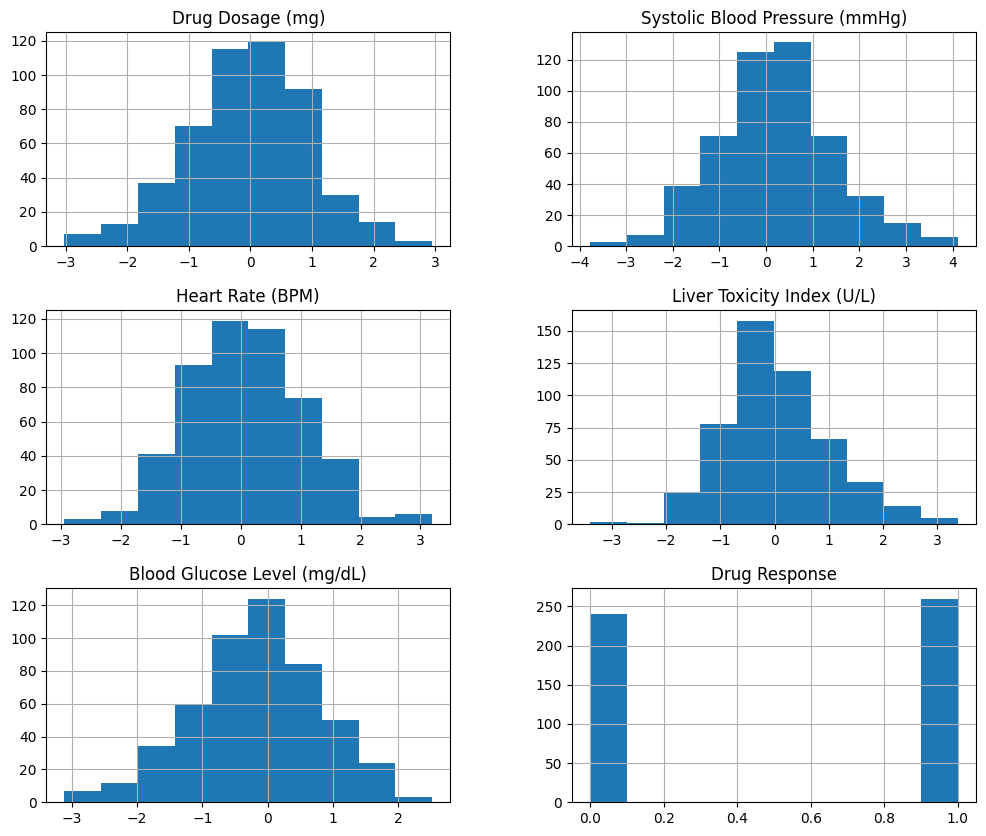

In [73]:
df.hist(figsize=(12,10))
plt.show()

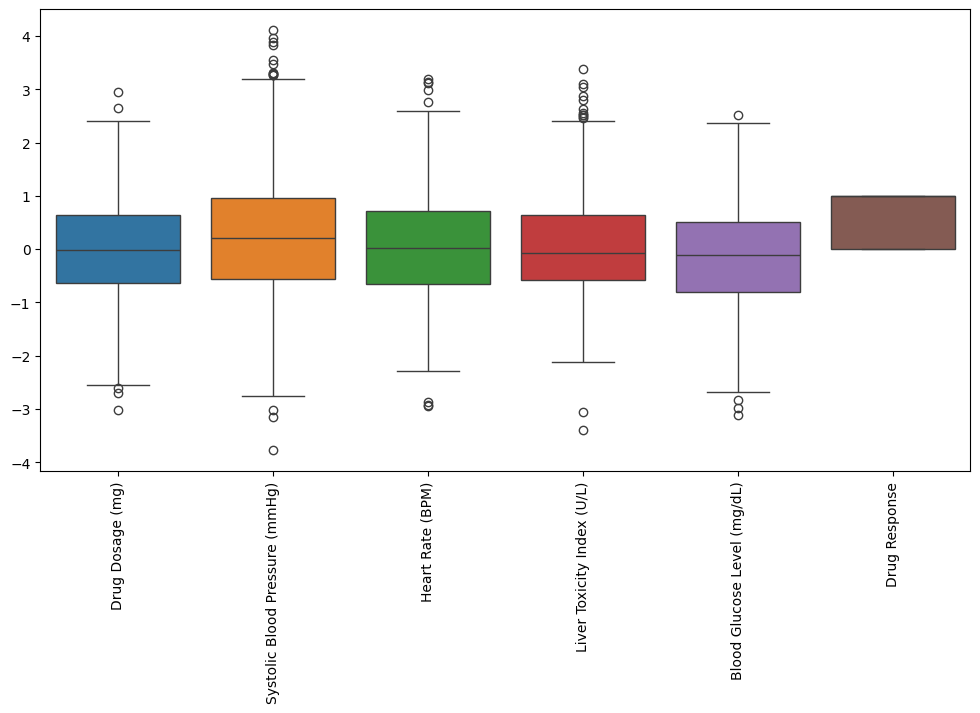

In [74]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

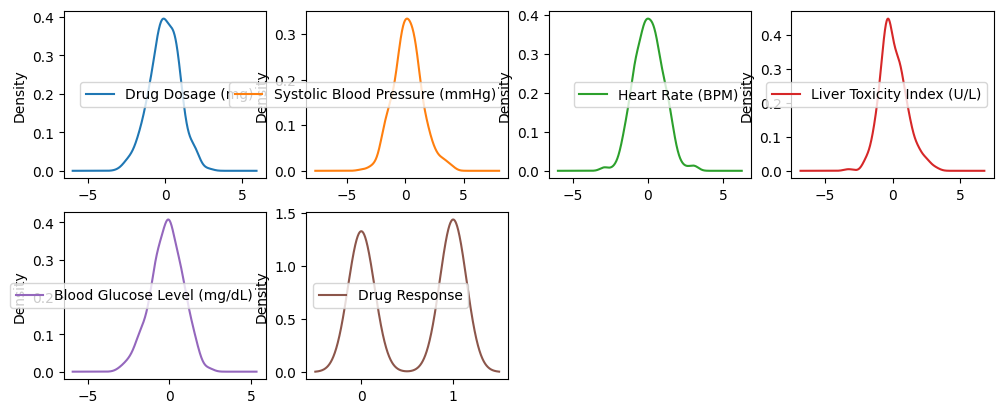

In [75]:
df.plot(kind='density', subplots=True, layout=(4,4),
        figsize=(12,10), sharex=False)
plt.show()

3.	Investigate feature correlations to discern relationships within the data.

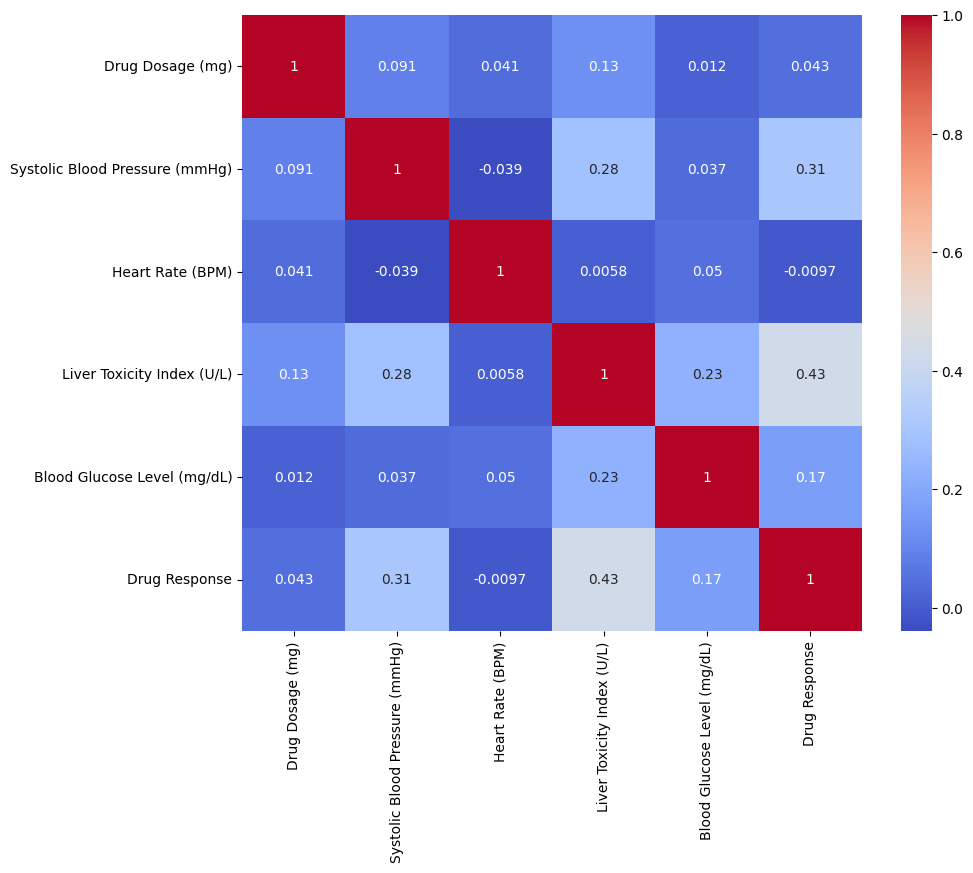

In [76]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

Task 2: Data Preprocessing

1.	Encode categorical variables if necessary.



In [77]:
#Encode Categorical Variables
le = LabelEncoder()

for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = le.fit_transform(df[column])

In [78]:
#Define Features and Target
X = df.drop("Drug Response", axis=1)
y = df["Drug Response"]

In [79]:
#Feature Scaling
scaler = StandardScaler()
X = scaler.fit_transform(X)

2.	Split the dataset into training and testing sets

In [80]:
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

Task 3: Data Visualization

Employ scatter plots, pair plots, or relevant visualizations to comprehend feature distributions and relationships.

Visualize class distributions to gauge dataset balance or imbalance

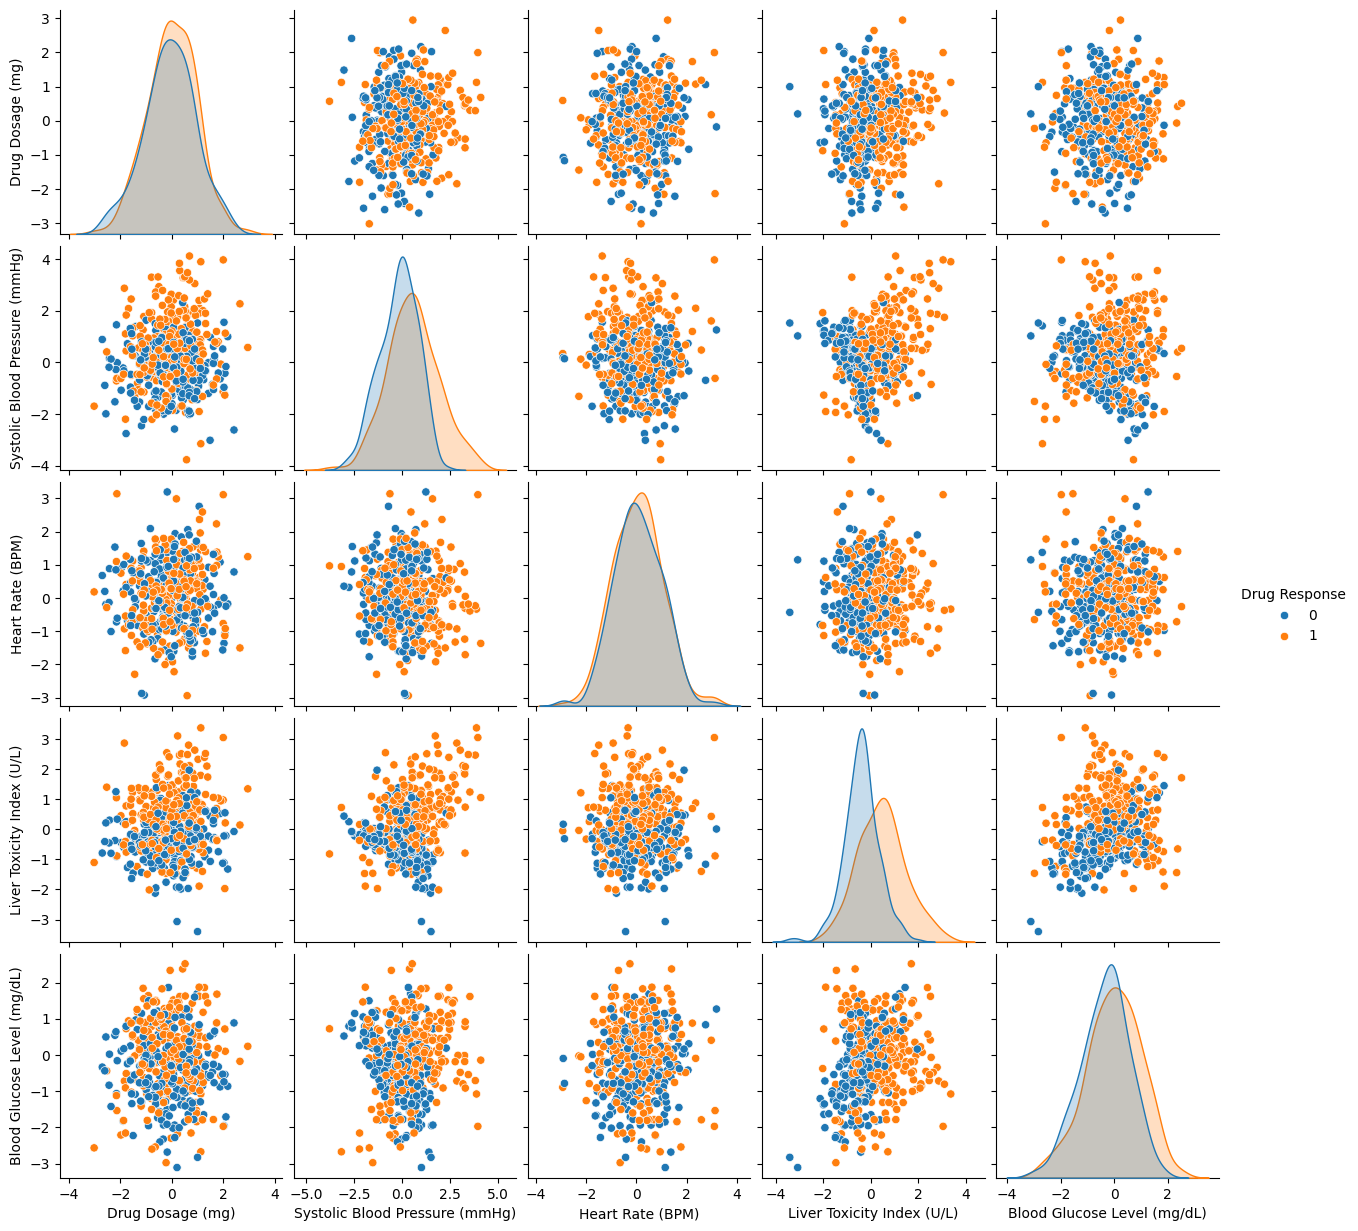

In [81]:
sns.pairplot(df, hue="Drug Response")

plt.show()

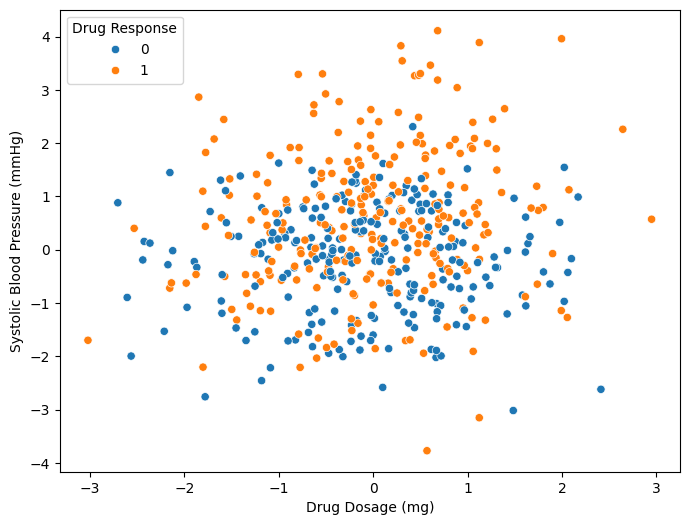

In [82]:
# Scatter plot
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df.iloc[:,0],
    y=df.iloc[:,1],
    hue=df["Drug Response"]
)

plt.xlabel(df.columns[0])
plt.ylabel(df.columns[1])

plt.show()

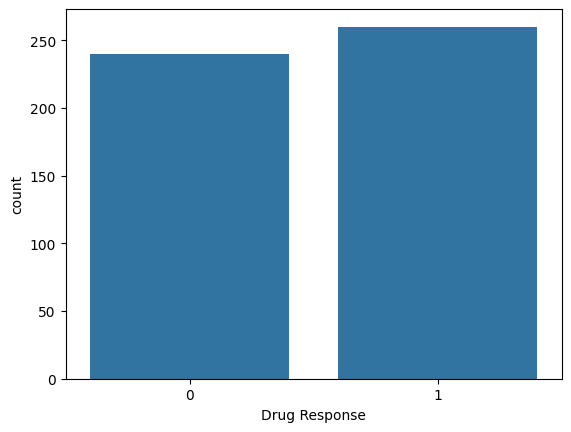

In [83]:
#Visualize class distributions to gauge dataset balance or imbalance
sns.countplot(x="Drug Response", data=df)
plt.show()

Task 4: SVM Implementation

1.	Implement a basic SVM classifier using Python libraries like scikit-learn.

2.	Train the SVM model on the training data.

3.	Evaluate model performance on the testing data using appropriate metrics (e.g., accuracy, precision, recall, F1-score).


In [84]:
#Create SVM Classifier
svm_model = SVC(kernel='linear')

In [85]:
#Train the Model
svm_model.fit(X_train, y_train)

SVC(kernel='linear')

In [86]:
#Predict on Testing Data
y_pred = svm_model.predict(X_test)

In [87]:

#Accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.78


In [88]:
#Precision, Recall, F1-Score
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.72      0.82      0.77        44
           1       0.84      0.75      0.79        56

    accuracy                           0.78       100
   macro avg       0.78      0.78      0.78       100
weighted avg       0.79      0.78      0.78       100



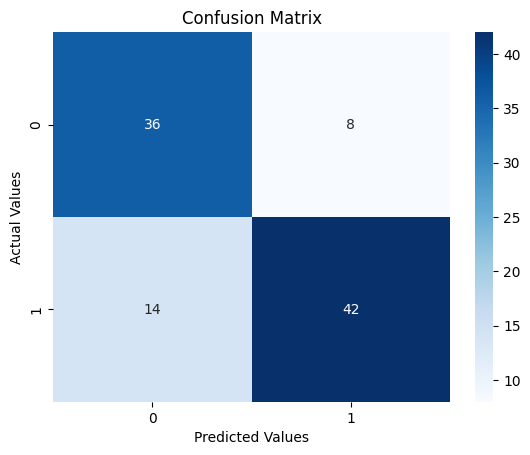

In [89]:
#Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")

plt.title("Confusion Matrix")

plt.show()

In [90]:
"""Result Analysis
The Support Vector Machine (SVM) model achieved an accuracy of approximately 78% on the testing dataset.

This indicates that the model correctly predicted drug responses for most patients. The model shows good performance in classifying whether a patient will respond positively to a drug or not.

However, some misclassifications still exist due to:

variability in patient biological responses,

overlapping feature distributions,

limited dataset size,

and possible noise in medical data.

Overall, the SVM model demonstrates effective classification capability for drug response prediction and can be further improved through hyperparameter tuning and kernel optimization.  """

'Result Analysis\nThe Support Vector Machine (SVM) model achieved an accuracy of approximately 78% on the testing dataset.\n\nThis indicates that the model correctly predicted drug responses for most patients. The model shows good performance in classifying whether a patient will respond positively to a drug or not.\n\nHowever, some misclassifications still exist due to:\n\nvariability in patient biological responses,\n\noverlapping feature distributions,\n\nlimited dataset size,\n\nand possible noise in medical data.\n\nOverall, the SVM model demonstrates effective classification capability for drug response prediction and can be further improved through hyperparameter tuning and kernel optimization.  '

Task 5: Visualization of SVM Results

Visualize classification results on the testing data.

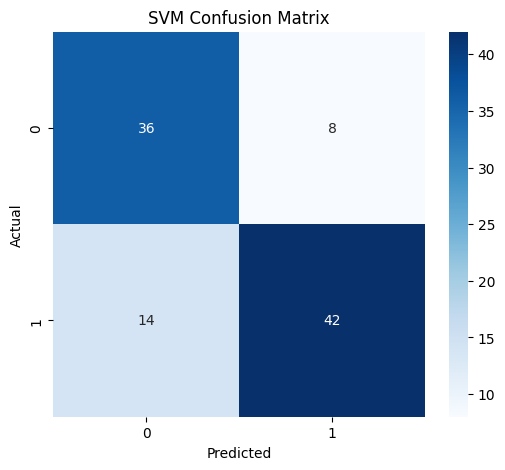

In [91]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("SVM Confusion Matrix")

plt.show()

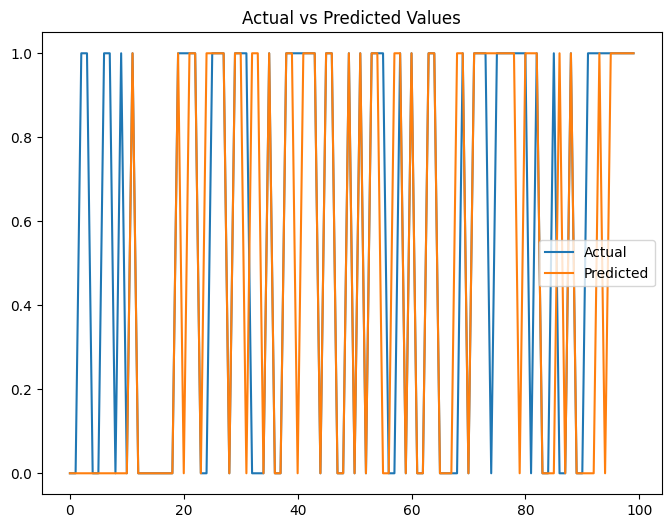

In [92]:
#Actual vs Predicted Visualization
plt.figure(figsize=(8,6))

plt.plot(y_test.values, label='Actual')
plt.plot(y_pred, label='Predicted')

plt.legend()

plt.title("Actual vs Predicted Values")

plt.show()

Task 6: Parameter Tuning and Optimization

1.	Experiment with different SVM hyperparameters (e.g., kernel type, regularization parameter) to optimize performance.


In [93]:
# Linear Kernel

linear_model = SVC(kernel='linear')

linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)

print("Linear Accuracy :",
      accuracy_score(y_test, linear_pred))

Linear Accuracy : 0.78


In [94]:
# Polynomial Kernel

poly_model = SVC(kernel='poly', degree=3)

poly_model.fit(X_train, y_train)

poly_pred = poly_model.predict(X_test)

print("Polynomial Accuracy :",
      accuracy_score(y_test, poly_pred))

Polynomial Accuracy : 0.7


In [95]:
# RBF Kernel

rbf_model = SVC(kernel='rbf')

rbf_model.fit(X_train, y_train)

rbf_pred = rbf_model.predict(X_test)

print("RBF Accuracy :",
      accuracy_score(y_test, rbf_pred))

RBF Accuracy : 0.84


Task 7: Comparison and Analysis

1.	Compare SVM performance with various kernels (e.g., linear, polynomial, radial basis function).

2.	Analyze SVM strengths and weaknesses for the dataset based on EDA and visualization results.

3.	Discuss practical implications of SVM in real-world classification tasks.


In [96]:
# Final Comparison

print("Linear Kernel Accuracy :",
      accuracy_score(y_test, linear_pred))

print("Polynomial Kernel Accuracy :",
      accuracy_score(y_test, poly_pred))

print("RBF Kernel Accuracy :",
      accuracy_score(y_test, rbf_pred))

Linear Kernel Accuracy : 0.78
Polynomial Kernel Accuracy : 0.7
RBF Kernel Accuracy : 0.84


In [97]:
""" RBF kernel achieved the highest accuracy of 84%, showing the best performance for this dataset.
    Linear kernel performed reasonably well with 78% accuracy.
    Polynomial kernel showed lower performance compared to other kernels.

    Strengths
    Effective in high-dimensional spaces
    Handles non-linear relationships
    provides good accuracy


    Weaknesses of SVM
    Sensitive to noise
    Computationally expensive
    Sensitive to parameter tuning


    Real-World Applications

    Drug response prediction
    Disease classification
    Personalized medicine
    Medical diagnosis

    Conclusion
SVM successfully classified drug responses using patient medical data.
RBF kernel performed best with 84% accuracy.  """

' RBF kernel achieved the highest accuracy of 84%, showing the best performance for this dataset.\n    Linear kernel performed reasonably well with 78% accuracy.\n    Polynomial kernel showed lower performance compared to other kernels.\n\n    Strengths \n    Effective in high-dimensional spaces\n    Handles non-linear relationships\n    provides good accuracy\n\n\n    Weaknesses of SVM\n    Sensitive to noise\n    Computationally expensive\n    Sensitive to parameter tuning\n    \n      \n    Real-World Applications\n\n    Drug response prediction\n    Disease classification\n    Personalized medicine\n    Medical diagnosis\n\n    Conclusion\nSVM successfully classified drug responses using patient medical data.\nRBF kernel performed best with 84% accuracy.  '